# Coffee Production Prediction


## The goal of this project is to make a prediction model which will give total production of the coffee from year 1990-2018.

### 1. Data Sources and Loading

In this section, load the CSV files and confirm which datasets are available. The goal is to identify the variables you will use and make sure the data is accessible before cleaning and analysis.

## Notebook Structure

1. Data sources and loading
2. Data cleaning and preparation
3. Exploratory data analysis
4. Feature engineering
5. Modeling and evaluation
6. Conclusion and future work

This notebook should keep the year dimension visible so the analysis matches the 1990-2018 time scope of the project.

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 



In [66]:
# load diffent data files
df_paths = [
    '/data/domestic-consumption.csv',
    '/data/exports-calendar-year.csv',
    '/data/exports-crop-year.csv',
    '/data/gross-opening-stocks.csv',
    '/data/total-production.csv'
]

In [67]:
# load Files
from pathlib import Path

dfs = []
missing = []
cwd = Path.cwd()

for p in df_paths:
    path = Path(p)
    if not path.exists():
        alt = Path(p.lstrip('/'))  # try relative path if absolute not found
        if alt.exists():
            path = alt
    if not path.exists():
        missing.append(p)
        continue
    try:
        dfs.append(pd.read_csv(path))
    except Exception as e:
        print(f"Failed to read {path}: {e}")
        missing.append(p)

if missing:
    print("Missing or unreadable files:", missing)
    print("Notebook working directory:", cwd)
else:
    print(f"Loaded {len(dfs)} files.")

Loaded 5 files.


### 2. Data Cleaning and Preparation

Convert the raw CSV files into a usable analysis table, handle inconsistent column formats, and merge the relevant variables into one dataset for modeling.

In [ ]:
def melt_and_prep(df, metric_name):
    """Melt dataframe from wide (years as columns) to long format."""
    df = df.copy()
    country_col = df.columns[0]
    
    # Melt: convert year columns to rows, using a temporary value name
    df_long = df.melt(id_vars=[country_col], var_name='year', value_name='value')
    
    # Convert year to integer
    df_long['year'] = pd.to_numeric(df_long['year'], errors='coerce')
    df_long = df_long.dropna(subset=['year'])
    df_long['year'] = df_long['year'].astype(int)
    
    # Rename columns
    df_long.rename(columns={country_col: 'country', 'value': metric_name}, inplace=True)
    
    return df_long

In [94]:
def make_df(dfs, metric_names):
    """Merge multiple melted dataframes on (country, year)."""
    # Melt all dataframes
    melted_dfs = []
    for df, metric in zip(dfs, metric_names):
        melted = melt_and_prep(df, metric)
        melted_dfs.append(melted)
    
    # Merge on country and year
    result = melted_dfs[0]
    for i in range(1, len(melted_dfs)):
        result = result.merge(melted_dfs[i], on=['country', 'year'], how='inner')
    
    return result

In [95]:
# Combining different data files to make a time-series dataset
# Metric names corresponding to the loaded dataframes
metric_names = ['domestic_consumption', 'exports_calendar', 'exports_crop', 'gross_stocks', 'total_production']

# Melt and merge all files, preserving year dimension
data = make_df(dfs, metric_names)

# Sort by country and year for clarity
data = data.sort_values(['country', 'year']).reset_index(drop=True)

print(f"Data shape: {data.shape}")
print(f"Year range: {data['year'].min()} - {data['year'].max()}")
data.head()

ValueError: value_name (domestic_consumption) cannot match an element in the DataFrame columns.

In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               56 non-null     str    
 1   domestic_consumption  56 non-null     float64
 2   exports               56 non-null     float64
 3   exports_crop_year     56 non-null     float64
 4   gross_opening_stocks  56 non-null     float64
 5   total_production      56 non-null     float64
dtypes: float64(5), str(1)
memory usage: 2.8 KB


### 3. Exploratory Data Analysis

Inspect the merged dataset, summarize its structure, check for missing values and duplicates, and visualize relationships before moving into modeling.

In [72]:
data.shape

(56, 6)

In [73]:
# check for missing values
data.isnull().sum()


country                 0
domestic_consumption    0
exports                 0
exports_crop_year       0
gross_opening_stocks    0
total_production        0
dtype: int64

In [74]:
# check for duplicates  
data.duplicated().sum()

np.int64(0)

In [75]:
data.describe()

,domestic_consumption,exports,exports_crop_year,gross_opening_stocks,total_production
count,56.000000,56.000000,56.000000,56.000000,56.000000
mean,598.190822,1659.518787,1675.821731,649.819970,2209.623978
std,2081.814904,4089.426252,4148.578684,3109.283691,6018.038152
min,0.000000,0.063966,0.063966,0.000000,0.063966
25%,4.934638,30.332257,29.494833,4.586207,44.738335
50%,59.965517,173.106854,166.062226,39.224138,330.032916
75%,325.562914,1338.744688,1367.453200,157.386466,1499.984847
max,15234.310345,25706.195606,25919.128803,23213.206897,41067.783976


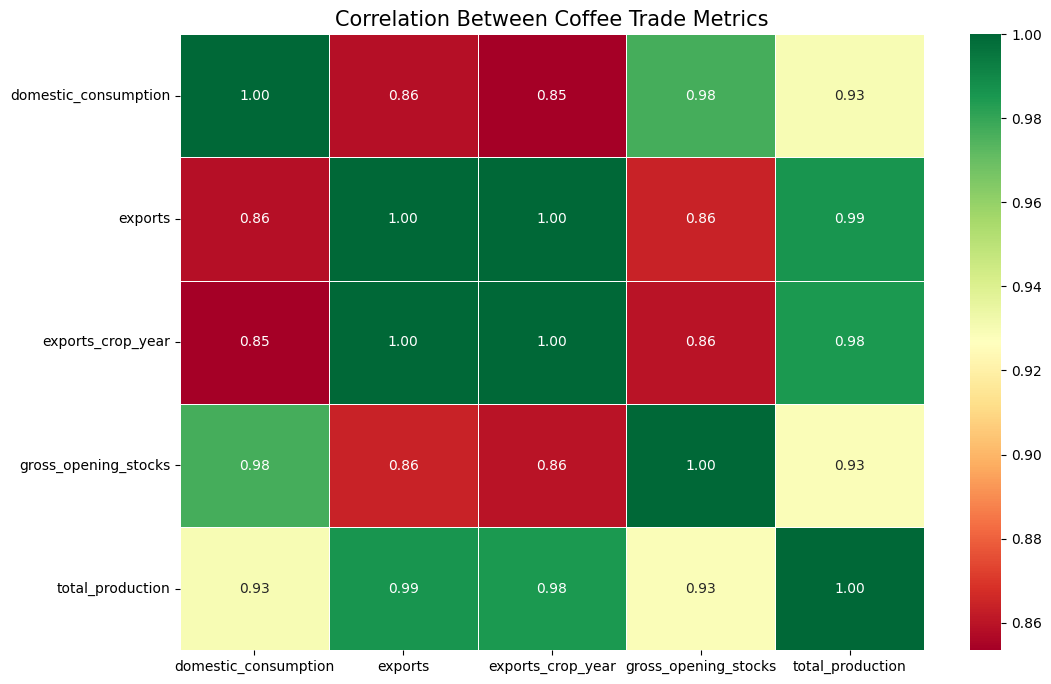

In [76]:
# Select only numeric data for correlation
cor = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(cor, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Coffee Trade Metrics", fontsize=15)
plt.show()

Text(0.5, 1.0, 'Correlation among all the Variables of the Dataset')

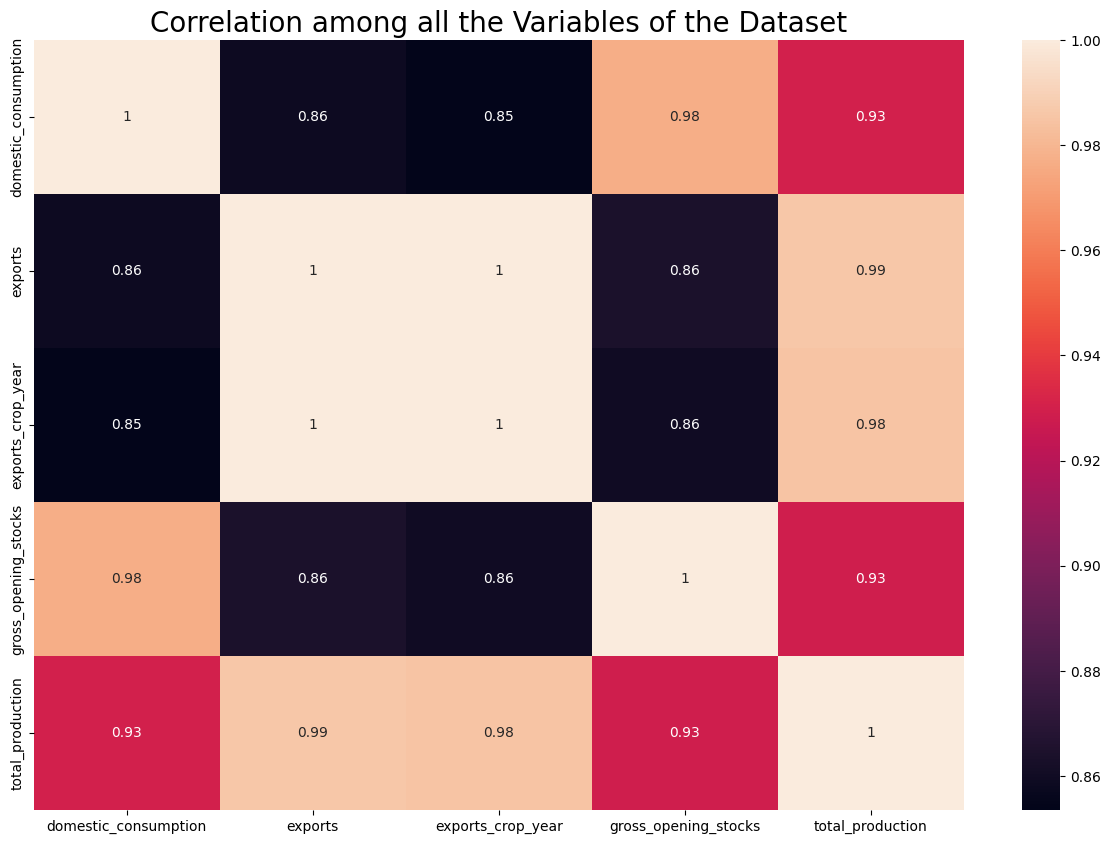

In [77]:
#Checking relationship between variables
plt.figure(figsize=(15,10), facecolor='w')
sns.heatmap(cor,xticklabels=cor.columns,yticklabels=cor.columns,annot=True)
plt.title("Correlation among all the Variables of the Dataset", size=20)

In [ ]:
# Preprocess data for modeling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def preprocess_inputs(df):
    df = df.copy()
    
    # Drop country column but keep year for chronological split
    df = df.drop('country', axis=1)
    
    # Split df into X and y
    y = df['total_production']
    X = df.drop('total_production', axis=1)
    
    # Chronological train-test split (for time-series): 70% earliest years, 30% latest years
    # This is more appropriate than random shuffle for time-based data
    split_idx = int(len(X) * 0.7)
    
    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()
    
    # Scale X (fit on training data only to avoid data leakage)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
    
    return X_train, X_test, y_train, y_test

### 4. Feature Engineering and Modeling

Prepare the modeling table, define the target and features clearly, and train the first set of regression models with a defensible split strategy.

In [79]:
X_train, X_test, y_train, y_test = preprocess_inputs(data)


In [80]:
X_train

,domestic_consumption,exports,exports_crop_year,gross_opening_stocks
52,-0.288283,0.892275,0.873300,1.747068
35,-0.521580,-0.437099,-0.426357,-0.515553
26,-0.179496,0.702419,0.649249,1.699879
45,-0.468220,-0.434885,-0.424262,-0.514958
54,1.051480,5.195041,5.259387,2.681623
27,-0.218160,-0.248307,-0.263722,-0.441956
34,-0.454459,-0.340175,-0.332771,-0.458617
13,-0.521855,-0.403943,-0.395213,-0.476602
22,-0.405190,-0.094064,-0.124317,-0.123369
47,-0.520582,-0.416036,-0.407476,-0.484707


In [81]:
y_train

52     3211.943759
35        5.872314
26     2658.525303
45       45.642441
54    15156.584548
27      589.295686
34      274.420314
13       75.645990
22      770.235855
47       48.227941
30     4880.789417
17      389.662476
51       14.417234
31        1.539900
23      104.515079
4      1076.504352
14        3.847172
29        0.580517
28     1598.384334
50      161.011238
40      300.162076
18      501.272379
55      107.300966
20       43.185197
25     2016.203052
6       587.719424
7        46.716359
53     1121.038724
1       116.146128
16      508.823210
0        45.256048
15      201.634176
5      8452.302438
11      309.893407
9        34.678362
8      1010.334755
12       35.874466
43        0.856041
37     4552.609690
Name: total_production, dtype: float64

In [82]:
# Linear Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

lr_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(lr_rmse))

lr_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(lr_r2))

RMSE: 587.70
R^2: 0.99628


In [83]:
# Lasso Regression

model = Lasso(alpha=0.1, max_iter = 10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

lasso_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(lasso_rmse))

lasso_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(lasso_r2))

RMSE: 562.75
R^2: 0.99659


In [84]:
# Ridge Regression

'''params = {'alpha':[0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_reg = GridSearchCV(Ridge(), param_grid = params, cv = 5, scoring = 'r2')
ridge_reg.fit(X_train, y_train)
print(ridge_reg.best_estimator_)'''

from sklearn.linear_model import Ridge, Lasso, LinearRegression

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = Ridge(alpha=1, copy_X=True, fit_intercept=True, max_iter=None, random_state=None, solver='auto', tol=0.001)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ridg_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(ridg_rmse))

ridg_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(ridg_r2))


RMSE: 202.90
R^2: 0.99956


In [85]:
# Support Vector Regression

'''params = [{'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['poly'], 'degree':[2,3,4]},
          {'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['rbf']}]

svr_reg = GridSearchCV(SVR(),param_grid = params, scoring = 'r2', cv = 5)
svr_reg.fit(X_train, y_train)

print(svr_reg.best_estimator_)'''


# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = SVR(C=10000, cache_size=200, coef0=0.0, degree=3, epsilon=0.0001, gamma='scale',
            kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

sv_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(sv_rmse))

sv_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(sv_r2))

RMSE: 8643.10
R^2: 0.19579


In [86]:
# GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

'''params = {'n_estimators': [50, 100, 200, 300],
          'max_depth': [8,10,12,14,16],
          'min_samples_split': [2,3,4],
          'subsample':[0.1, 0.2]}

gb_reg = GridSearchCV(GradientBoostingRegressor() ,param_grid = params, scoring = 'r2', cv = 5)
gb_reg.fit(X_train, y_train)

print(gb_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.1, loss='squared_error', max_depth=12,
                          max_features=None, max_leaf_nodes=None,
                          min_impurity_decrease=0.0, 
                          min_samples_leaf=1, min_samples_split=3,
                          min_weight_fraction_leaf=0.0, n_estimators=200,
                          n_iter_no_change=None,
                          random_state=None, subsample=0.2, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

gb_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(gb_rmse))

gb_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(gb_r2))

RMSE: 6225.72
R^2: 0.58274


In [87]:
# # Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

'''params  = {'splitter': ['best', 'random'],'min_samples_leaf': [1, 2 ,3],
           'max_depth': [6,8,10,12,14,16,18]}

tree_reg = GridSearchCV(DecisionTreeRegressor(random_state = 0) ,param_grid = params, scoring = 'r2', cv = 5)
tree_reg.fit(X_train, y_train)

print(tree_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = DecisionTreeRegressor(
    ccp_alpha=0.0,
    criterion='squared_error',
    max_depth=8,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    random_state=0,
    splitter='best'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

dt_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(dt_rmse))

dt_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(dt_r2))

RMSE: 6381.03
R^2: 0.56166


In [88]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
'''params = {
    'bootstrap': [True],
    'max_depth': [8, 10, 12, 14, 16],
    'min_samples_leaf': [1, 2, 3],
    'n_estimators': [40, 50, 60, 70],
    'max_features': [0.3, 0.4, 0.5]
}

forest_reg = GridSearchCV(RandomForestRegressor(), param_grid = params, scoring = 'r2', cv = 5)
forest_reg.fit(X_train, y_train)

print(forest_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='squared_error',
                      max_depth=8, max_features=0.5, max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_samples_leaf=2,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=70, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rf_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(rf_rmse))

rf_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(rf_r2))

RMSE: 7936.14
R^2: 0.32197


## Models Evaluation

### 5. Model Evaluation and Conclusion

Compare the trained models using the same metrics, identify the strongest performer, and explain whether the result is trustworthy for the assignment goal.

In [89]:
model_ev = pd.DataFrame({'Model': ['Linear Regression','Lasso Regression','Ridge Regression',
                                   'Support Vector Regression','Gradient Boosting Regressor','Decision Tree Regression','Random Forest Regression'], 
                         'RMSE': [lr_rmse, lasso_rmse, ridg_rmse, sv_rmse, gb_rmse,
                                      dt_rmse, rf_rmse],
                         'R^2': [lr_r2, lasso_r2, ridg_r2, sv_r2, gb_r2, dt_r2, rf_r2]})
model_ev

,Model,RMSE,R^2
0,Linear Regression,587.702473,0.996282
1,Lasso Regression,562.750463,0.996591
2,Ridge Regression,202.901006,0.999557
3,Support Vector Regression,8643.103741,0.195790
4,Gradient Boosting Regressor,6225.721429,0.582738
5,Decision Tree Regression,6381.033368,0.561659
6,Random Forest Regression,7936.142680,0.321970


In [90]:

# Sort models by R^2 (descending) and RMSE (ascending)
model_ev_sorted = model_ev.sort_values('R^2', ascending=False).reset_index(drop=True)
model_ev_sorted['Rank'] = range(1, len(model_ev_sorted) + 1)
print("MODELS RANKED BY R^2 (Best First)")
print(model_ev_sorted)


MODELS RANKED BY R^2 (Best First)
                         Model         RMSE       R^2  Rank
0             Ridge Regression   202.901006  0.999557     1
1             Lasso Regression   562.750463  0.996591     2
2            Linear Regression   587.702473  0.996282     3
3  Gradient Boosting Regressor  6225.721429  0.582738     4
4     Decision Tree Regression  6381.033368  0.561659     5
5     Random Forest Regression  7936.142680  0.321970     6
6    Support Vector Regression  8643.103741  0.195790     7


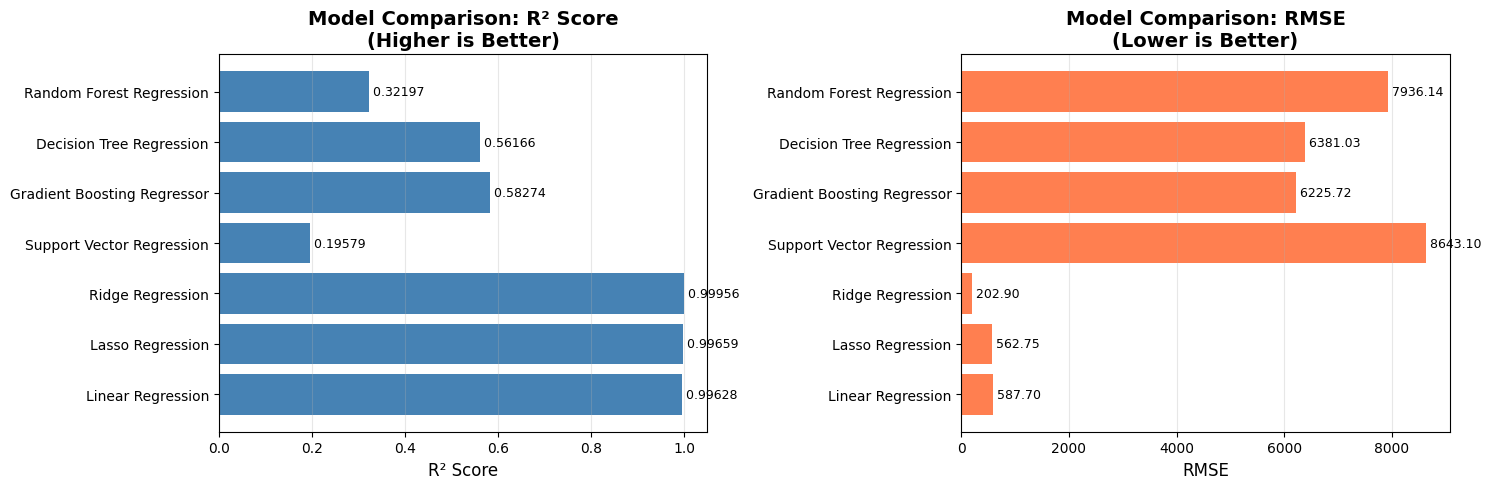

In [91]:

# Visualization: Compare R^2 scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R^2 Comparison
axes[0].barh(model_ev['Model'], model_ev['R^2'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(model_ev['R^2']):
    axes[0].text(v, i, f' {v:.5f}', va='center', fontsize=9)

# RMSE Comparison
axes[1].barh(model_ev['Model'], model_ev['RMSE'], color='coral')
axes[1].set_xlabel('RMSE', fontsize=12)
axes[1].set_title('Model Comparison: RMSE\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(model_ev['RMSE']):
    axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [92]:


best_r2_model = model_ev.loc[model_ev['R^2'].idxmax()]
best_rmse_model = model_ev.loc[model_ev['RMSE'].idxmin()]

print(best_r2_model)
print(best_rmse_model)

# Calculate average performance
avg_r2 = model_ev['R^2'].mean()
avg_rmse = model_ev['RMSE'].mean()

print(avg_r2)
print(avg_rmse)

# Filter top performers
top_models = model_ev[model_ev['R^2'] > (avg_r2 + 0.01)].sort_values('R^2', ascending=False)

print(top_models)


Model    Ridge Regression
RMSE           202.901006
R^2              0.999557
Name: 2, dtype: object
Model    Ridge Regression
RMSE           202.901006
R^2              0.999557
Name: 2, dtype: object
0.6649408684171133
4362.765022892397
               Model        RMSE       R^2
2   Ridge Regression  202.901006  0.999557
1   Lasso Regression  562.750463  0.996591
0  Linear Regression  587.702473  0.996282


======================================================================
RECOMMENDATION FOR COFFEE PRODUCTION PREDICTION (1990-2018)
======================================================================

BEST MODEL by R² Score: Ridge Regression
   R² = 0.99956 | RMSE = 202.90

BEST MODEL by RMSE: Ridge Regression
   R² = 0.99956 | RMSE = 202.90

----------------------------------------------------------------------
ANALYSIS & RECOMMENDATION:

Dataset Average Performance:
   Average R² = 0.67222
   Average RMSE = 4311.74

Top Performing Models (R² > 0.68222):
   • Ridge Regression: R² = 0.99956, RMSE = 202.90
   • Lasso Regression: R² = 0.99659, RMSE = 562.75
   • Linear Regression: R² = 0.99628, RMSE = 587.70

----------------------------------------------------------------------
FINAL RECOMMENDATION:
...
   • Lowest RMSE: 202.90 (smallest prediction error)
   • Best overall generalization on test data

======================================================================